In [15]:
import matplotlib.pyplot as plt
import os, duckdb
import pandas as pd


# Load The Data

In [2]:
cwd = os.getcwd()
parent = os.path.dirname(cwd)

over_world_dim = os.path.join(parent, 'data', 'signs_pretty_overworld.csv')
nether_dim = os.path.join(parent, 'data', 'signs_pretty_nether.csv')
end_dim = os.path.join(parent, 'data', 'signs_pretty_end.csv')

end_df = pd.read_csv(end_dim)
nether_df = pd.read_csv(nether_dim)
over_world_df = pd.read_csv(over_world_dim)

# Work on end visualization


### Grab all cody signs

In [3]:
filtered_end_df = end_df[end_df['plain_text'].str.contains('codysmile11', case=False, na=False)]
filtered_end_df.tail()

,x,y,z,is_1.12.2,plain_text
96945,76151,67,-112115,0,codysmile11 Has Been Here :) 24 July 2024
96951,-75995,60,-25633,0,codysmile11 Has Been Here :) 25 Sep 2024
97632,25001,76,2,0,DouglasTheThird 09/10/2023 Fuck Codysmile11
98431,127580,55,0,1,codysmile11
98453,127779,55,-1,1,codysmile11


### Get the dates of all cody signs

In [4]:
filtered_end_df = filtered_end_df.copy()

dates = filtered_end_df['plain_text'].str.extract(
    r'(\d{1,2}\s+[A-Za-z]{3,9}\s+\d{4})',
    expand=False
).str.strip()

filtered_end_df['cody_sign_date'] = (
    pd.to_datetime(dates, format='%d %b %Y', errors='coerce')
    .fillna(pd.to_datetime(dates, format='%d %B %Y', errors='coerce'))
)

filtered_end_df = filtered_end_df[
    filtered_end_df['cody_sign_date'].isna() |
    filtered_end_df['cody_sign_date'].dt.year.between(2013, 2026)
]

filtered_end_df.head(20)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
19,150,213,5,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
22,151,211,1,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
24,151,212,1,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
25,87,165,-27,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
26,150,214,5,0,codysmile11 Has Been Here :) 24 July 2024,2024-07-24
30,87,170,-29,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
32,87,172,-30,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
38,87,173,-30,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
42,87,168,-28,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25
50,87,169,-29,0,codysmile11 Has Been Here :) 25 Sep 2024,2024-09-25


### Sort by Date

In [5]:
sorted_end_df = filtered_end_df.sort_values(by=['cody_sign_date'], ascending=True)
sorted_end_df = sorted_end_df.dropna()
sorted_end_df.tail(20)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
5187,418,3,1998,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5078,316,175,1997,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5238,395,162,2001,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5239,388,110,2010,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5242,396,161,2003,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5246,390,110,2011,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5247,399,161,2010,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5293,404,162,2012,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5248,395,162,2000,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11
5255,388,110,2013,0,codysmile11 Has Been Here :) 11 June 2025,2025-06-11


### Signs By Year Amount

cody_sign_date
2022.0       1
2023.0     391
2024.0    8000
2025.0     180
Name: cody_sign_date, dtype: int64

Total Signs Count
8572


cody_sign_date
1.0       41
4.0      187
6.0      180
7.0     1757
8.0       13
9.0      804
10.0    5455
12.0     135
Name: cody_sign_date, dtype: int64


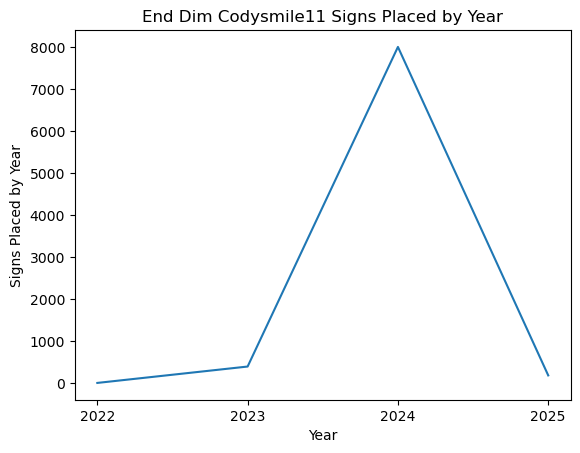

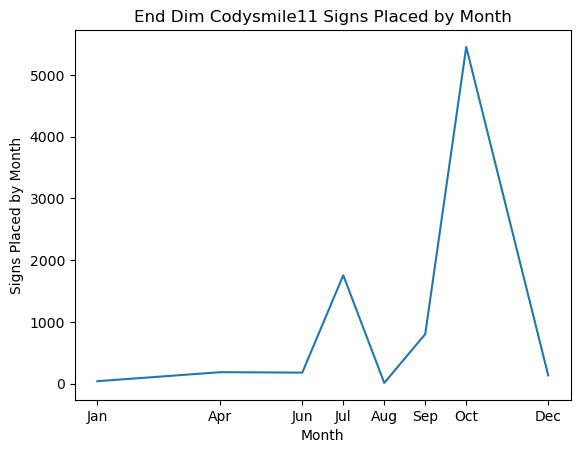

In [6]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

year_count_end = filtered_end_df.groupby(filtered_end_df['cody_sign_date'].dt.year)['cody_sign_date'].count()
print(year_count_end)

month_count_end = filtered_end_df.groupby(filtered_end_df['cody_sign_date'].dt.month)['cody_sign_date'].count()

print('\nTotal Signs Count')
print(sum(month_count_end))
print('\n')

print(month_count_end)

plt.plot(year_count_end)
plt.title("End Dim Codysmile11 Signs Placed by Year")
plt.xlabel("Year")
plt.ylabel("Signs Placed by Year")
plt.xticks(year_count_end.index.astype(int), year_count_end.index.astype(int))
plt.show()

plt.plot(month_count_end)
plt.title("End Dim Codysmile11 Signs Placed by Month")
plt.xlabel("Month")
plt.ylabel("Signs Placed by Month")
plt.xticks(month_count_end.index.astype(int), [month_names[int(i)-1] for i in month_count_end.index])
plt.show()

# Work On Nether Visualizations

### Grab All Cody Signs

In [7]:
filtered_nether_df = nether_df[nether_df['plain_text'].str.contains('Codysmile11', case=False, na=False)]

filtered_nether_df.head()

,x,y,z,is_1.12.2,plain_text
0,8412,120,-7998,0,codysmile11 was here :) 19 Nov 2023
1,8424,120,-7998,0,codysmile11 was here :) 19 Nov 2023
2,8441,120,-7998,0,codysmile11 was here :) 19 Nov 2023
3,8463,120,-7998,0,codysmile11 was here :) 19 Nov 2023
14,-7778,57,6781,1,codysmile11


### Get all dates from the signs

In [8]:
filtered_nether_df = filtered_nether_df.copy()

dates = filtered_nether_df['plain_text'].str.extract(
    r'(\d{1,2}\s+[A-Za-z]{3,9}\s+\d{4})',
    expand=False
).str.strip()

filtered_nether_df['cody_sign_date'] = (
    pd.to_datetime(dates, format='%d %b %Y', errors='coerce')
    .fillna(pd.to_datetime(dates, format='%d %B %Y', errors='coerce'))
)

filtered_nether_df = filtered_nether_df[
    filtered_nether_df['cody_sign_date'].isna() |
    filtered_nether_df['cody_sign_date'].dt.year.between(2013, 2026)
]

filtered_nether_df.head(10)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
0,8412,120,-7998,0,codysmile11 was here :) 19 Nov 2023,2023-11-19
1,8424,120,-7998,0,codysmile11 was here :) 19 Nov 2023,2023-11-19
2,8441,120,-7998,0,codysmile11 was here :) 19 Nov 2023,2023-11-19
3,8463,120,-7998,0,codysmile11 was here :) 19 Nov 2023,2023-11-19
14,-7778,57,6781,1,codysmile11,NaT
15,-7939,63,5019,1,codysmile11,NaT
16,-7936,63,5017,1,codysmile11,NaT
29,-8181,79,4713,0,codysmile11 Has Been Here :) 27 Sep 2024,2024-09-27
30,-8179,79,4713,0,codysmile11 Has Been Here :) 27 Sep 2024,2024-09-27
31,-8179,79,4716,0,codysmile11 Has Been Here :) 27 Sep 2024,2024-09-27


### Sort The Dates

In [9]:
sorted_nether_df = filtered_nether_df.sort_values(by=['cody_sign_date'], ascending=True)
sorted_nether_df = sorted_nether_df.dropna()
sorted_nether_df.head()

,x,y,z,is_1.12.2,plain_text,cody_sign_date
51919,7785,120,-25150,1,codysmile11 9 may 2022 :),2022-05-09
7030,-12003,121,-9939,1,codysmile11 yo 10 july 2022,2022-07-10
64778,12506,120,-17756,1,codysmile11 4 Feb 2023,2023-02-04
64779,12507,120,-17769,1,codysmile11 4 Feb 2023,2023-02-04
84095,-10,126,50005,1,codysmile11 at the TOP 5 Feb 2023 :),2023-02-05


# Make The Graphs

cody_sign_date
2022.0        2
2023.0     6980
2024.0    70256
2025.0      324
Name: cody_sign_date, dtype: int64

Total Signs Count
77562


cody_sign_date
1.0      5719
2.0       413
3.0      1267
4.0      1143
5.0        20
6.0      1546
7.0     29175
8.0     22685
9.0      4087
10.0     5238
11.0     1662
12.0     4607
Name: cody_sign_date, dtype: int64


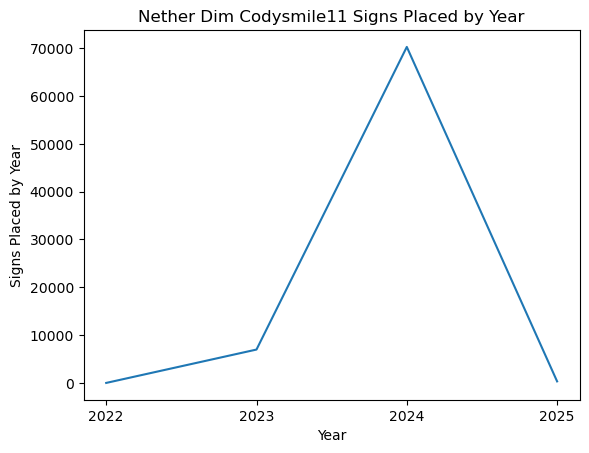

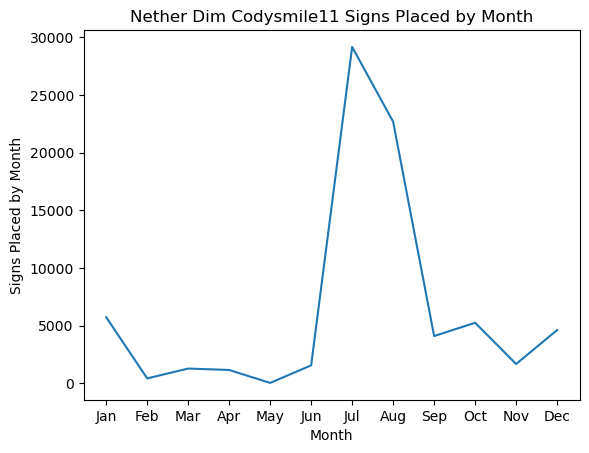

In [10]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

year_count_nether = filtered_nether_df.groupby(filtered_nether_df['cody_sign_date'].dt.year)['cody_sign_date'].count()
print(year_count_nether)

month_count_nether = filtered_nether_df.groupby(filtered_nether_df['cody_sign_date'].dt.month)['cody_sign_date'].count()

print('\nTotal Signs Count')
print(sum(month_count_nether))
print('\n')

print(month_count_nether)

plt.plot(year_count_nether)
plt.title("Nether Dim Codysmile11 Signs Placed by Year")
plt.xlabel("Year")
plt.ylabel("Signs Placed by Year")
plt.xticks(year_count_nether.index.astype(int), year_count_nether.index.astype(int))
plt.show()

plt.plot(month_count_nether)
plt.title("Nether Dim Codysmile11 Signs Placed by Month")
plt.xlabel("Month")
plt.ylabel("Signs Placed by Month")
plt.xticks(month_count_nether.index.astype(int), [month_names[int(i)-1] for i in month_count_nether.index])
plt.show()

# Get Overworld Data

### Get All Cody Signs Overworld

In [11]:
filtered_overworld_df = over_world_df[over_world_df['plain_text'].str.contains('Codysmile11', case=False, na=False)]

print(filtered_overworld_df.shape)
filtered_overworld_df.head()

(493565, 5)


,x,y,z,is_1.12.2,plain_text
16,77,156,863,0,codysmile11 ☑ was here 31 Aug 2023
17,77,159,850,0,codysmile11 ☑ was here 31 Aug 2023
18,79,153,856,0,codysmile11 ☑ was here 31 Aug 2023
19,77,175,853,0,codysmile11 ☑ was here 31 Aug 2023
26,77,152,832,0,codysmile11 ☑ was here 31 Aug 2023


### Get all dates

In [12]:
filtered_overworld_df = filtered_overworld_df.copy()

dates = filtered_overworld_df['plain_text'].str.extract(
    r'(\d{1,2}\s+[A-Za-z]{3,9}\s+\d{4})',
    expand=False
).str.strip()

filtered_overworld_df['cody_sign_date'] = (
    pd.to_datetime(dates, format='%d %b %Y', errors='coerce')
    .fillna(pd.to_datetime(dates, format='%d %B %Y', errors='coerce'))
)

filtered_overworld_df = filtered_overworld_df[
    filtered_overworld_df['cody_sign_date'].isna() |
    filtered_overworld_df['cody_sign_date'].dt.year.between(2013, 2026)
]

filtered_overworld_df.head(10)

,x,y,z,is_1.12.2,plain_text,cody_sign_date
16,77,156,863,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
17,77,159,850,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
18,79,153,856,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
19,77,175,853,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
26,77,152,832,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
27,77,154,836,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
28,77,145,842,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
29,77,154,842,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
30,77,153,836,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31
31,77,151,836,0,codysmile11 ☑ was here 31 Aug 2023,2023-08-31


### Sort the dates in the df


In [13]:
sorted_overworld_df = filtered_overworld_df.sort_values(by=['cody_sign_date'], ascending=True)
sorted_overworld_df = sorted_overworld_df.dropna()
sorted_overworld_df.head()

,x,y,z,is_1.12.2,plain_text,cody_sign_date
2308904,120738,32,7083,0,codysmile11 was here :) 16 Jan 2021,2021-01-16
1190908,-879,54,-26097,1,codysmile11 5 may 2022 :),2022-05-05
1334064,43481,76,39560,1,codysmile11 9 may 2022 :),2022-05-09
1331014,44754,78,40002,1,codysmile11 9 may 2022,2022-05-09
1331424,44374,73,39040,1,codysmile11 9 may 2022 :),2022-05-09


### Make overworld graphs

cody_sign_date
2021.0         1
2022.0       152
2023.0     68071
2024.0    400625
2025.0     13221
2026.0        22
Name: cody_sign_date, dtype: int64

Total Signs Count
482092


cody_sign_date
1.0       8134
2.0       2936
3.0      10055
4.0       6204
5.0       2270
6.0      30438
7.0      43987
8.0      89350
9.0      93665
10.0    107091
11.0     41805
12.0     46157
Name: cody_sign_date, dtype: int64


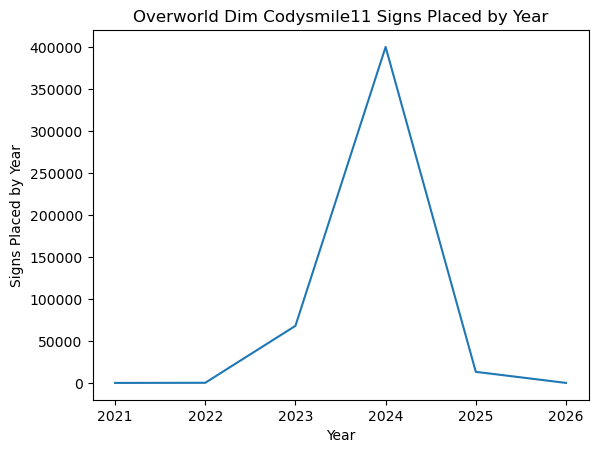

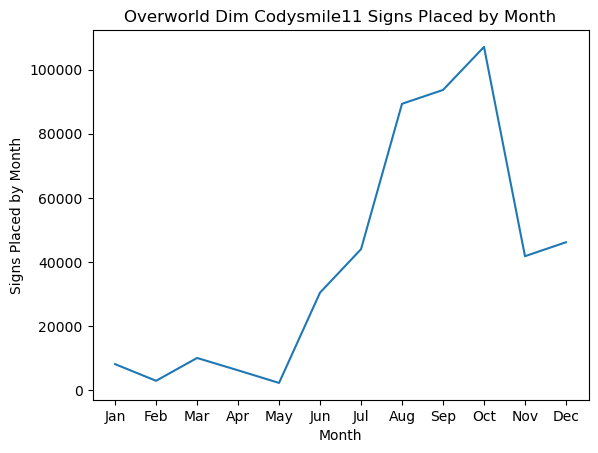

In [14]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

year_count_overworld = filtered_overworld_df.groupby(filtered_overworld_df['cody_sign_date'].dt.year)['cody_sign_date'].count()
print(year_count_overworld)

month_count_overworld = filtered_overworld_df.groupby(filtered_overworld_df['cody_sign_date'].dt.month)['cody_sign_date'].count()

print('\nTotal Signs Count')
print(sum(month_count_overworld))
print('\n')

print(month_count_overworld)

plt.plot(year_count_overworld)
plt.title("Overworld Dim Codysmile11 Signs Placed by Year")
plt.xlabel("Year")
plt.ylabel("Signs Placed by Year")
plt.xticks(year_count_overworld.index.astype(int), year_count_overworld.index.astype(int))
plt.show()

plt.plot(month_count_overworld)
plt.title("Overworld Dim Codysmile11 Signs Placed by Month")
plt.xlabel("Month")
plt.ylabel("Signs Placed by Month")
plt.xticks(month_count_overworld.index.astype(int), [month_names[int(i)-1] for i in month_count_overworld.index])
plt.show()